In [1]:
import pandas as pd

weather_data_cleaned = pd.read_csv('GlobalWeatherRepository_Cleaned.csv')
weather_data_scaled = pd.read_csv('GlobalWeatherRepository_Cleaned_Scaled.csv')

In [2]:
weather_data_scaled.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15:00,0.221311,79.8,Partly Cloudy,...,-0.273430,0.215621,1,1,2026-05-28 04:50:00,2026-05-28 18:50:00,12:12 PM,01:11 AM,Waxing Gibbous,0.55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45:00,-0.401639,66.2,Partly cloudy,...,-0.626087,-0.570196,1,1,2026-05-28 05:21:00,2026-05-28 19:54:00,12:58 PM,02:14 AM,Waxing Gibbous,0.55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45:00,-0.073770,73.4,Sunny,...,-0.176812,-0.046318,1,1,2026-05-28 05:40:00,2026-05-28 19:50:00,01:15 PM,02:14 AM,Waxing Gibbous,0.55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45:00,-1.442623,43.3,Light drizzle,...,-0.645411,-0.605335,1,1,2026-05-28 06:31:00,2026-05-28 21:11:00,02:12 PM,03:31 AM,Waxing Gibbous,0.55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45:00,0.172131,78.8,Partly cloudy,...,7.117874,7.744769,5,10,2026-05-28 06:12:00,2026-05-28 17:55:00,01:17 PM,12:38 AM,Waxing Gibbous,0.55


In [3]:
weather_data_cleaned['location_name'].value_counts().head(10)

location_name
Kabul           710
Warsaw          710
Accra           710
Kyiv            710
Tashkent        710
Vatican City    710
N'djamena       710
Baghdad         710
Tokyo           710
Amman           710
Name: count, dtype: int64

In [4]:
weather_data_cleaned['last_updated'].head(10)

0    2024-05-16 13:15:00
1    2024-05-16 10:45:00
2    2024-05-16 09:45:00
3    2024-05-16 10:45:00
4    2024-05-16 09:45:00
5    2024-05-16 04:45:00
6    2024-05-16 05:45:00
7    2024-05-16 12:45:00
8    2024-05-16 18:45:00
9    2024-05-16 10:45:00
Name: last_updated, dtype: object

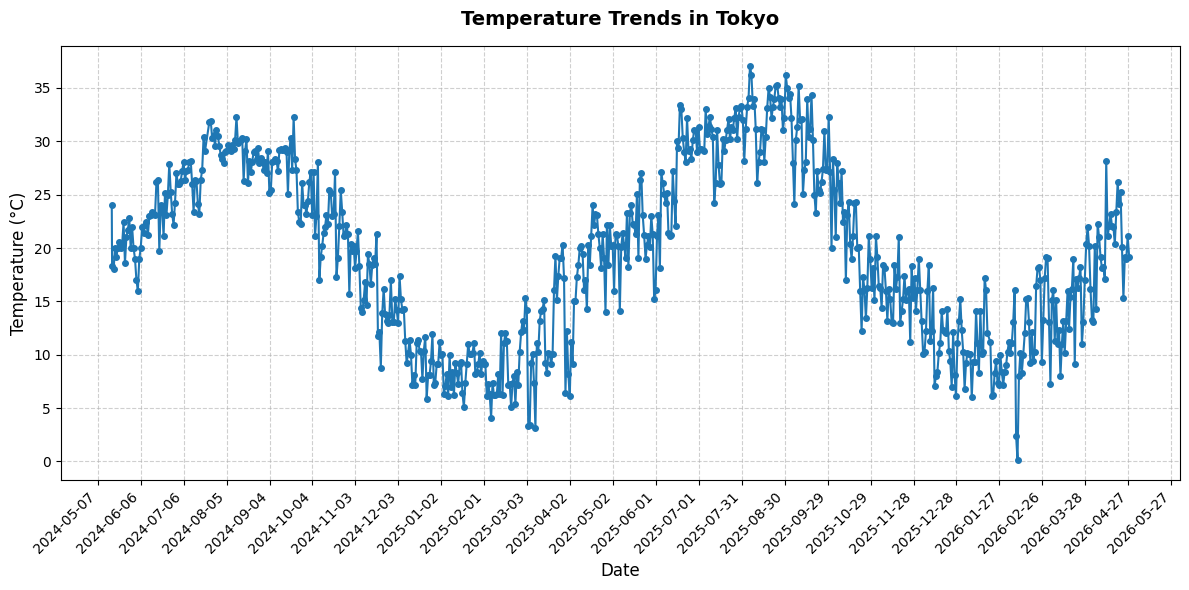

In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# 1. Make sure 'last_updated' is a datetime object so matplotlib handles it correctly
tokyo_data = weather_data_cleaned[weather_data_cleaned['location_name'] == 'Tokyo'].copy()
tokyo_data['last_updated'] = pd.to_datetime(tokyo_data['last_updated'])

# Sort by date to make sure the line draws smoothly
tokyo_data = tokyo_data.sort_values('last_updated')

# 2. Plotting
plt.figure(figsize=(12, 6))
plt.plot(tokyo_data['last_updated'], tokyo_data['temperature_celsius'], marker='o', markersize=4, linewidth=1.5)

# 3. Clean up the x-axis ticks
ax = plt.gca() # Get current axis

# Set tick intervals (e.g., show a tick every 7 days)
# Note: If your dataset spans months, change 'days=7' to 'months=1'
ax.xaxis.set_major_locator(mdates.DayLocator(interval=30)) 

# Format how the date looks (YYYY-MM-DD)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.title('Temperature Trends in Tokyo', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)  
plt.ylabel('Temperature (°C)', fontsize=12)

# Rotate labels slightly so they don't overlap
plt.xticks(rotation=45, ha='right')

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

The data exhibits a classic, well-defined annual seasonal pattern. You can clearly identify two distinct seasonal cycles:

- Summer Peaks: Temperatures consistently crest between 35°C and 37°C around August of both 2024 and 2025.
- Winter Troughs: Temperatures drop significantly to their lowest points between 0°C and 5°C around January/February of 2025 and 2026.

C:\Users\Hp\AppData\Local\Temp\ipykernel_22556\413692727.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


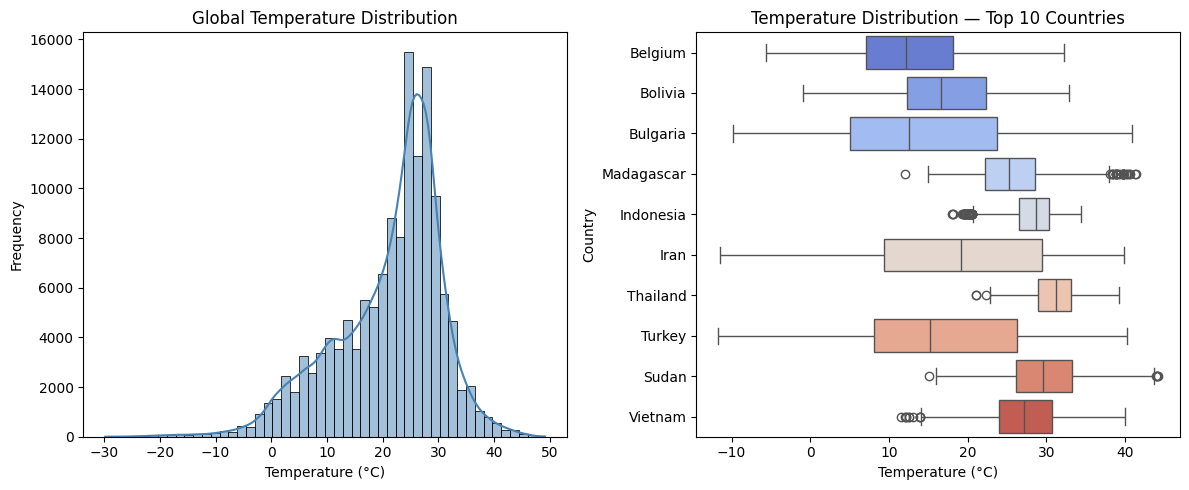

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Temperature distribution globally
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(weather_data_cleaned['temperature_celsius'], bins=50, kde=True, color='steelblue')
plt.title('Global Temperature Distribution')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
top10_countries = weather_data_cleaned['country'].value_counts().head(10).index
sns.boxplot(
    data=weather_data_cleaned[weather_data_cleaned['country'].isin(top10_countries)],
    x='temperature_celsius',
    y='country',
    palette='coolwarm'
)
plt.title('Temperature Distribution — Top 10 Countries')
plt.xlabel('Temperature (°C)')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

**Global Temperature Distribution:**
- Distribution is **slightly left-skewed**, with the bulk of readings between **10°C and 35°C** — reflecting that most cities in the dataset are in temperate to tropical zones
- Peak is around **25–28°C**, suggesting the dataset is dominated by warm-climate cities
- The long left tail confirms the cold-climate outliers we saw earlier (Mongolia, Canada, Kazakhstan) are a minority

**Temperature by Country:**
- **Belgium & Bulgaria** show the widest IQR, indicating high seasonal variability — typical of continental European climates
- **Indonesia & Thailand** have very tight, high boxes — consistently hot and humid year-round with little variation ✅ expected for tropical countries
- **Sudan & Vietnam** sit at the warmest end, with medians above 28°C
- **Iran & Turkey** show wide ranges — both experience extreme summers and cold winters
- **Madagascar** has two outlier points on both ends — likely reflects its diverse geography (coastal vs highland regions)
- **Bolivia** has a surprisingly cool median (~15°C) despite being in South America — explained by its high-altitude location (La Paz sits at 3,600m)

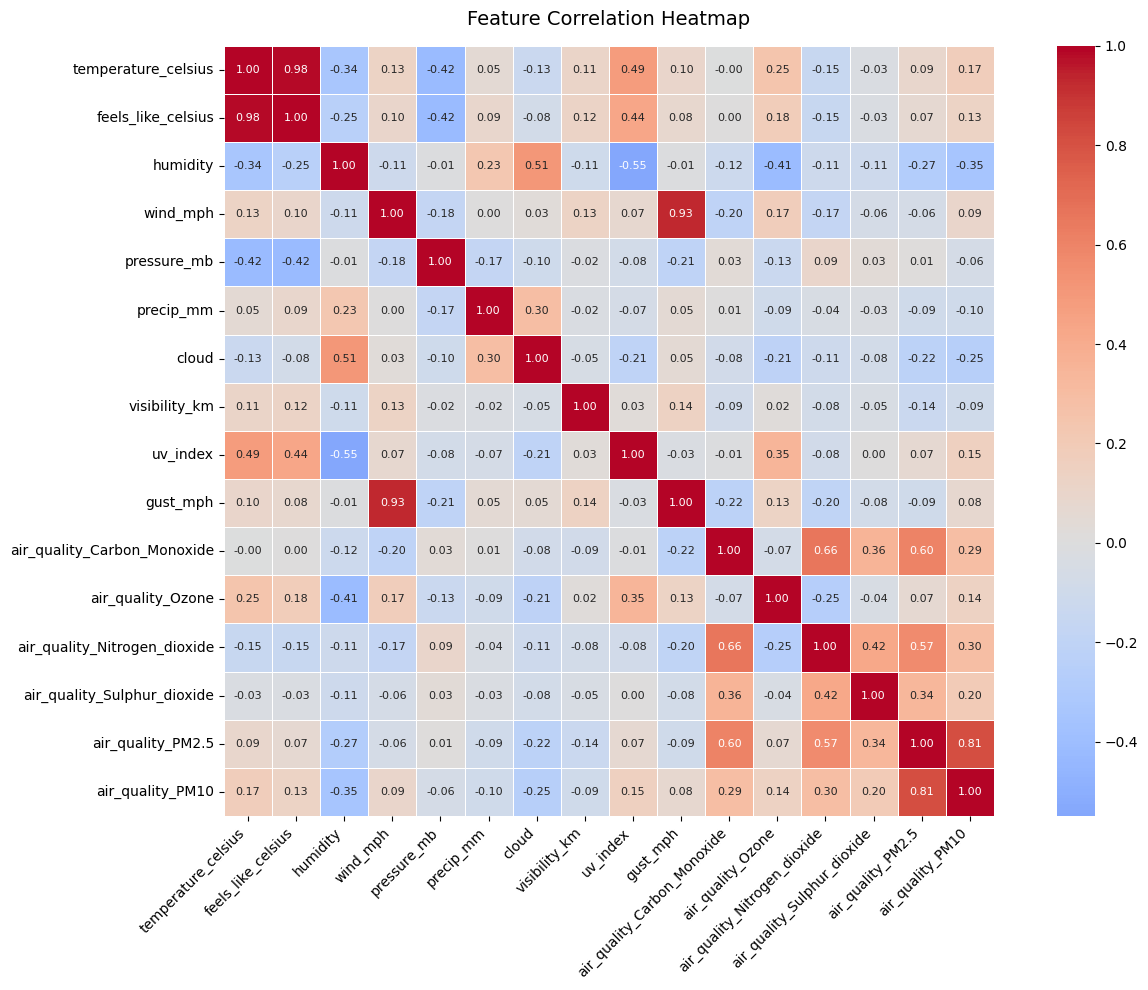

In [7]:
# Select relevant numeric columns for correlation
corr_cols = [
    'temperature_celsius', 'feels_like_celsius', 'humidity', 'wind_mph',
    'pressure_mb', 'precip_mm', 'cloud', 'visibility_km', 'uv_index',
    'gust_mph', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
    'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
    'air_quality_PM2.5', 'air_quality_PM10'
]

corr_matrix = weather_data_cleaned[corr_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Feature Correlation Heatmap', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

1. **High Collinearity and Feature Redundancy**  
A prominent feature of this matrix is the presence of near-perfect positive correlations among specific pairs of variables. Notably, temperature_celsius and feels_like_celsius exhibit a correlation of 0.98, indicating they capture virtually identical variance. Similarly, wind dynamics show an extreme correlation of 0.95 between wind_mph and gust_mph. In the domain of air quality, particulate matter sizes air_quality_PM2.5 and air_quality_PM10 are highly tied at 0.81.  
    - For statistical modeling, these pairs present a severe risk of multicollinearity. Keeping both variables in a linear model would artificially inflate coefficient variance, suggesting that one from each pair should be dropped during feature engineering.  

2. **Atmospheric Chemistry and Environmental Clusters**  
The bottom-right quadrant reveals a dense cluster of positive correlations among chemical air pollutants. Air_quality_Carbon_Monoxide is strongly correlated with air_quality_Nitrogen_dioxide (0.66) and air_quality_PM2.5 (0.60).  
    - This strong linear behavior implies a shared underlying source—most likely fossil fuel combustion from vehicular traffic or industrial activity. When one traffic-related pollutant rises, the others rise in tandem, creating a distinct "urban pollution signature" in the data.

3. **Meteorological Drivers of Ground-Level Ozone**  
The heatmap clearly captures the environmental mechanics of ozone ($O_3$) formation. Air_quality_Ozone displays a positive correlation with uv_index (0.35) and a notable negative correlation with humidity (-0.41). Furthermore, humidity and uv_index share a strong inverse relationship of -0.55.  
    - This aligns perfectly with atmospheric science: high humidity typically coincides with heavy cloud cover (supported by the 0.51 correlation between cloud and humidity), which blocks ultraviolet radiation. Because UV light acts as a catalyst for chemical reactions that create ground-level ozone, a drop in UV rays and an increase in moisture naturally suppresses ozone levels.
    
4. **Orthogonal and Independent Variables**   
While many variables are tightly interwoven, visibility_km and precip_mm (precipitation) stand out as statistically isolated. Visibility_km maintains negligible coefficients across all features, never exceeding a absolute correlation of 0.14. Interestingly, precip_mm shows only mild positive relationships with cloud (0.30) and humidity (0.23), and shows almost zero correlation with any air quality pollutants.
    - This indicates that while rainfall requires clouds, the volume of precipitation does not scale linearly with cloud cover or humidity in this dataset. Because these features carry unique, independent signals, they are highly valuable "orthogonal" inputs for machine learning models, as they cannot be predicted by the other weather metrics.

In [8]:
# Top 15 most common weather conditions
condition_counts = weather_data_cleaned['condition_text'].value_counts().head(15).reset_index()
condition_counts.columns = ['condition', 'count']

fig = px.bar(
    condition_counts,
    x='count',
    y='condition',
    orientation='h',
    color='count',
    color_continuous_scale='Blues',
    title='Top 15 Most Common Weather Conditions',
    labels={'count': 'Number of Records', 'condition': 'Weather Condition'}
)

fig.update_layout(
    height=500,
    yaxis={'categoryorder': 'total ascending'},
    coloraxis_showscale=False
)

fig.show()

1. **Clear Class Imbalance (Dominant Conditions)**

The dataset is heavily dominated by just two primary weather states: **Sunny** and **Partly cloudy**.

* Each of these two categories accounts for nearly **40,000 records**, dwarfing every other weather condition in the dataset.
* Together, they represent the vast majority of the total data volume. Any predictive machine learning model trained on this dataset without adjustment will likely have a strong bias toward predicting clear or partially clear days.

---

2. **Data Cleaning & Label Inconsistency (Critical Issue)**

Looking closely at the categorical labels on the y-axis, there are immediate data quality issues that require **text normalization** before any further analysis:

* **Duplicate Categories due to Casing:** The dataset has separate bars for **"Partly cloudy"** (lowercase 'c', ~40k records) and **"Partly Cloudy"** (uppercase 'C', ~8.5k records). These represent the exact same meteorological state and should be merged.
* **Overlapping Synonyms:** There are separate entries for **"Clear"** (~7k records) and **"Sunny"** (~40k records). Depending on the data source, these are often functionally identical during daytime hours. Similarly, **"Cloudy"** exists as a tiny fraction compared to **"Overcast"** and the two "Partly cloudy" variants.

---

3. **The "Long Tail" of Rain and Low-Visibility Events**

Beyond the top 5–6 categories, the distribution drops off drastically into a "long tail" of less frequent weather events (fewer than 5,000 records each):

* **Precipitation Segmentation:** Rain events are split into highly specific micro-categories: *Patchy rain nearby, Light rain, Light rain shower, Moderate or heavy rain with thunder, Moderate rain, Patchy light rain with thunder,* and *Light drizzle*.
* **Low-Visibility/Atmospheric Moisture:** **Mist** (~5.5k) is significantly more common in this dataset than **Fog** (~1.5k).

### recommended actions

> "An initial inspection of the weather condition distributions reveals a critical data cleaning requirement. The categorical target variable contains duplicate classes resulting from inconsistent string casing, specifically separating **'Partly cloudy'** and **'Partly Cloudy'**. To ensure statistical validity, these text labels must be normalized to a uniform lowercase convention and merged. Furthermore, the dataset exhibits an extreme class imbalance: benign conditions like 'Sunny' and 'Partly cloudy' combine for approximately 80,000 records, while severe or wet weather conditions like 'Moderate rain' or 'Fog' register in negligible numbers (under 2,000 records each)."

> "The horizontal bar chart highlights the severe right-skewed distribution of environmental states captured in the dataset. Fair-weather metrics dominate the observations, with 'Sunny' and the primary 'Partly cloudy' cohort each nearing 40,000 instances. Conversely, precipitation events are highly fragmented across multiple minor classifications ranging from 'Light drizzle' to 'Moderate or heavy rain with thunder.' For predictive modeling or risk analysis, this distribution suggests that group-level aggregation—such as consolidating all rain-variant subcategories into a single 'Precipitation' class—is necessary to provide machine learning algorithms with sufficient sample sizes per class."

## 🛠 Suggested Action Plan for Feature Engineering

| Identified Problem | Affected Labels | Recommended Solution |
| --- | --- | --- |
| **Inconsistent Casing** | `Partly cloudy` & `Partly Cloudy` | Apply `.str.title()` or `.str.lower()` in Pandas to merge them into a single category. |
| **High Fragmentation** | All 7 distinct rain/thunder categories | Bucket them into a broader categorical feature like `Rain / Storm`. |
| **Severe Class Imbalance** | `Sunny`/`Partly cloudy` vs. everything else | Use stratified sampling for train/test splits, or apply downsampling/SMOTE if utilizing this as a target variable. |

In [9]:
fig = px.scatter(
    weather_data_cleaned.sample(5000, random_state=42),  # sample for performance
    x='temperature_celsius',
    y='wind_mph',
    color='humidity',
    size='precip_mm',
    hover_data=['country', 'condition_text'],
    color_continuous_scale='Viridis',
    title='Wind Speed vs Temperature (colored by Humidity)',
    labels={
        'temperature_celsius': 'Temperature (°C)',
        'wind_mph': 'Wind Speed (mph)',
        'humidity': 'Humidity (%)'
    }
)

fig.update_layout(height=550)
fig.show()

1. The "Right-Triangular" or Bound Distribution

The most immediate structural insight is the geometric shape of the scatter plot. The data forms a rough right-triangle or localized dome:

* **The Cold Ceiling:** At colder temperatures (below 10°C), data points are sparse and generally capped at lower wind speeds, except for a few prominent mid-to-high wind anomalies around 0°C to 10°C.
* **The Warm Funnel:** As temperatures increase between 15°C and 30°C, the variance in wind speed expands significantly, showing a dense column of points ranging from 0 mph up to a peak of nearly 37 mph.
* **The Scorching Drop-off:** Beyond 35°C, the data sharply drops off. At extreme high temperatures (35°C to 50°C), there are virtually no high-wind records; the points are highly concentrated at the very bottom, close to 0–5 mph.

2. Humidity Clusters and Temperature Interdependence

The color gradient (ranging from dark purple for low humidity to bright yellow/green for 100% humidity) reveals strong meteorological banding:

* **High-Humidity/Cold-to-Warm Cluster:** Bright yellow and light green bubbles dominate the 0°C to 25°C temperature range across all wind speeds. This suggests that in this dataset, cooler to mild days are overwhelmingly humid.
* **Low-Humidity/Hot Zone:** Looking at the bottom right corner (temperatures between 30°C and 40°C), there is a distinct cluster of teal, dark blue, and faint purple markers. This clearly indicates that **the hottest days in this dataset are structurally dry (low humidity)**.

3. Wind Speed vs. Humidity Dynamics

If you look at the size and distribution of the bubbles vertically:

* **High-Wind Moisture:** The larger, prominent bubbles at the higher wind brackets (15 mph to 30 mph) are consistently yellow and light green (high humidity).
* **Still-Air Desiccation:** The few genuinely low-humidity points (darker blue/teal) are strictly confined to lower wind speeds (under 15 mph). You do not see high-wind, low-humidity environments in this dataset.

### Meteorological Phase Space Analysis

> "The cross-distribution of wind speed and ambient temperature exhibits a bounded, non-linear relationship. Rather than a uniform or linear trend, the data points form a distinct clustered envelope that peaks between 20°C and 30°C, where wind speeds span their entire 0 to 37 mph variance. Crucially, extreme thermal environments constrain wind behavior; at temperatures exceeding 35°C, high-wind events are completely absent, giving way to a stagnant, low-velocity profile hovering under 10 mph."

### Microclimate and Humidity Interaction

> "Integrating relative humidity into the multi-variable analysis reveals a stark atmospheric division. A robust, high-humidity regime (indicated by yellow and light-green color values near 80% to 100%) dominates the lower and mid-tier temperature spectrum from -10°C up to 25°C. Conversely, a distinct low-humidity transition occurs as temperatures eclipse the 30°C threshold. In this high-heat zone, the atmospheric profile shifts entirely toward lower moisture levels (teal and blue gradients), showing that extreme heat in this dataset is highly coupled with dry, low-wind conditions."

## 📊 Summary of Feature Extremes

| Quadrant / Zone | Temperature Range | Wind Speed Profile | Humidity Profile | Meteorological Interpretation |
| --- | --- | --- | --- | --- |
| **Left / Moderate Cold** | -10°C to 10°C | Low to Moderate | Very High (~90-100%) | Chilly, damp, or overcast conditions. |
| **Center / Peak Variance** | 15°C to 30°C | Full Range (0–37 mph) | Moderate to High | Highly dynamic weather; storm/gust windows. |
| **Bottom Right / High Heat** | 30°C to 45°C | Strictly Low (<15 mph) | Low (~20-50%) | Hot, dry, and stagnant air masses. |

In [10]:
# Filter out countries with very few records for reliable analysis
min_records = 100
reliable_countries = (
    weather_data_cleaned.groupby('country')
    .filter(lambda x: len(x) >= min_records)
)

# Re-plot with reliable countries only
top_aq_countries = (
    reliable_countries.groupby('country')['air_quality_PM2.5']
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

fig = px.bar(
    top_aq_countries,
    x='air_quality_PM2.5',
    y='country',
    orientation='h',
    color='air_quality_PM2.5',
    color_continuous_scale='Reds',
    title='Top 15 Countries by Average PM2.5 (min. 100 records)',
    labels={
        'air_quality_PM2.5': 'Average PM2.5 (µg/m³)',
        'country': 'Country'
    }
)

fig.update_layout(
    height=500,
    yaxis={'categoryorder': 'total ascending'},
    coloraxis_showscale=False
)

fig.show()

### 1. The Triple-Digit Concentration Tier

At the apex of the visualization, **China, India, and Saudi Arabia** form a distinct, high-exposure tier, with average PM2.5 levels climbing between **100 $\mu\text{g/m}^3$ and 110 $\mu\text{g/m}^3$**. The presence of these nations at the top of the distribution represents an extreme public health threshold, exceeding international safety recommendations by a factor of twenty.

* **Core Insight:** The massive scale of these numbers indicates that hundreds of millions of people in these regions are exposed to chronic, dangerous levels of particulate matter on a daily basis, driving elevated risks of respiratory and cardiovascular diseases.

### 2. Dual Drivers of Particulate Pollution: Industrial vs. Crustal Dust

An analysis of the featured countries reveals that the top fifteen list is divided between two entirely different environmental and socioeconomic mechanisms:

* **The Anthropogenic/Industrial Group:** Nations such as China, India, Bangladesh, Indonesia, and Vietnam are characterized by rapid industrialization, high population densities, coal-reliant energy grids, heavy vehicular traffic, and agricultural biomass burning.
* **The Arid/Geographic Dust Group:** In contrast, nations like Saudi Arabia, Kuwait, Bahrain, Mauritania, the United Arab Emirates, and Qatar display elevated PM2.5 baselines heavily driven by natural geography. These regions are subject to hyper-arid climates, minimal vegetation cover, and frequent, large-scale dust storms that loft immense volumes of natural mineral crust into the lower atmosphere.

### 3. The Global Dispersion and 50 $\mu\text{g/m}^3$ Baseline Floor

The distribution exhibits a gradual, tightly bounded decline after the top four nations, establishing a clear baseline "floor" around **50 to 60 $\mu\text{g/m}^3$** for the remainder of the list. This long tail spans multiple continents, pulling in South American valleys (Chile, which suffers from unique mountain topography that traps urban smog), Southeast Asian tropical zones (Malaysia), and West African urban centers (Nigeria).

* **Core Insight:** The fact that the 15th-ranked nation (Nigeria) still sits at roughly **50 $\mu\text{g/m}^3$** (ten times the WHO limit) proves that severe air pollution is not an isolated regional issue, but a cross-continental challenge spanning varying levels of economic development and geographic terrains.

---

## 📊 Summary Appendix Table

| Pollution Severity | PM2.5 Range ($\mu\text{g/m}^3$) | Representative Countries | Primary Pollution Catalyst |
| --- | --- | --- | --- |
| **Critical Tier** | 95 – 110+ | China, India, Saudi Arabia | Megacity vehicular/industrial smog combined with severe regional desert dust. |
| **High Tier** | 65 – 90 | Kuwait, Chile, Bangladesh, Indonesia | Thermal inversions in valley topography, heavy manufacturing, and coal combustion. |
| **Elevated Baseline** | 50 – 65 | Bahrain, Mauritania, Malaysia, UAE, Vietnam, Qatar, Pakistan, Nigeria | Seasonal sub-Saharan dust (Harmattan), tropical biomass burning, and rapid urbanization. |

---


In [11]:
# Check PM2.5 stats per top country
top_countries = top_aq_countries['country'].tolist()

print("=== PM2.5 Stats per Country ===\n")
print(weather_data_cleaned[weather_data_cleaned['country'].isin(top_countries)]
      .groupby('country')['air_quality_PM2.5']
      .agg(['mean', 'median', 'min', 'max', 'count'])
      .sort_values('mean', ascending=False)
      .round(2))

=== PM2.5 Stats per Country ===

                        mean  median    min    max  count
country                                                  
China                 109.61  112.65   7.50  161.4    707
India                 102.13  100.75   5.20  161.4    707
Saudi Arabia           99.53   97.96   9.40  161.4    708
Kuwait                 87.13   82.34  12.40  161.4    708
Chile                  81.00   60.50   8.45  161.4    706
Bangladesh             67.21   57.28   2.60  161.4    708
Indonesia              67.13   37.56   7.70  161.4   1419
Bahrain                64.46   59.60  14.50  161.4    709
Mauritania             63.20   45.29   2.90  161.4    708
Malaysia               59.07   51.43   4.95  161.4    708
United Arab Emirates   57.39   52.17   8.45  161.4    709
Vietnam                57.25   48.10   0.50  161.4   1162
Qatar                  56.92   51.80  12.45  161.4    707
Pakistan               51.69   46.25   8.25  161.4    707
Nigeria                50.56   38.65   

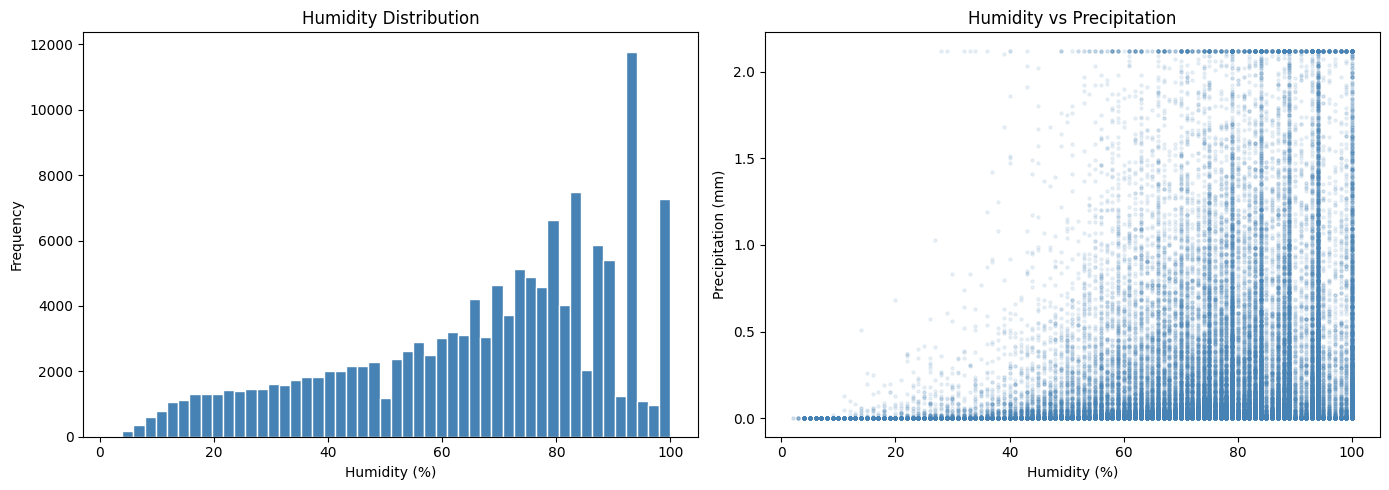

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Humidity distribution
axes[0].hist(weather_data_cleaned['humidity'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Humidity Distribution')
axes[0].set_xlabel('Humidity (%)')
axes[0].set_ylabel('Frequency')

# Humidity vs Precipitation scatter
axes[1].scatter(
    weather_data_cleaned['humidity'],
    weather_data_cleaned['precip_mm'],
    alpha=0.1,
    color='steelblue',
    s=5
)
axes[1].set_title('Humidity vs Precipitation')
axes[1].set_xlabel('Humidity (%)')
axes[1].set_ylabel('Precipitation (mm)')

plt.tight_layout()
plt.show()


### 1. Left-Skewed Humidity Distribution and Reporting Artifacts

The **Humidity Distribution** histogram demonstrates a stark, left-skewed (negatively skewed) distribution. The frequency of observations increases steadily as humidity rises, peaking dramatically in the **90% to 100%** range.

* **Data Anomaly / Reporting Artifact:** There are highly visible, sudden spikes and drops in the upper register—most notably a massive spike near **93%**, followed by a sharp drop, and another resurgence at **100%**. These sharp variations suggest potential sensor artifacts, discretization during data collection (e.g., rounding values to specific integers), or automated flagging from specific weather stations when conditions hit saturation point.

### 2. Humidity as a Boundary Condition for Precipitation

The **Humidity vs Precipitation** scatter plot highlights a classic meteorological threshold effect. At lower humidity levels (under 20%), precipitation is practically non-existent, clinging strictly to the **0.0 mm** baseline. As humidity climbs past **40%**, the variance in precipitation expands dramatically, creating a triangular or fan-shaped distribution.

* **Core Insight:** This pattern confirms that high relative humidity acts as a strict boundary condition or a *necessary but insufficient* requirement for rain. While it rarely or never rains at low humidity, high humidity does not automatically guarantee rain—evident from the dense accumulation of points sitting at 0.0 mm even when humidity is at 100%.

### 3. Data Clipping and Ceilings in Precipitation Data

A striking feature of the scatter plot is the solid, horizontal line of data points stretching across the very top of the y-axis at exactly **2.1 mm** (ranging from roughly 25% to 100% humidity).

* **Core Insight:** This straight horizontal boundary indicates a clear data clipping or ceiling effect. This usually happens because of sensor measurement limits (e.g., a rain gauge that maxes out at a specific depth per interval) or a data preprocessing step where precipitation values above 2.1 mm were capped or winsorized to handle extreme outliers.

---

## 📊 Summary Key Performance Matrix

| Variable / Relationship | Visual Metric / Shape | Statistical Implication | Meteorological Interpretation |
| --- | --- | --- | --- |
| **Humidity Baseline** | Left-Skewed Histogram | Dataset is heavily dominated by damp, high-humidity environments. | Likely captured during a wet season, coastal region, or consistently humid climate zone. |
| **Precipitation Top Limit** | Flat line at **2.1 mm** | Data capping/clipping artifact. | Sensor constraint or intentional data winsorization during preprocessing. |
| **Humidity vs. Rain** | Fan-shaped (Heteroscedastic) Scatter | Lower boundary restriction; variance increases with the x-axis. | Moisture saturation is required to trigger rainfall, but air column dynamics dictate the actual volume. |

---

## 📝 Concluding Modeling Recommendations

> "From a machine learning and feature engineering perspective, these distributions present unique challenges. The heavy left-skew of the humidity feature means models will be highly trained on saturated states but may struggle with dry-air anomalies. Furthermore, when predicting precipitation using humidity, algorithms must accommodate severe heteroscedasticity—where the error variance scales up alongside the humidity percentage. Finally, the artificial cap at 2.1 mm must be accounted for, as standard regression models will overpredict or underpredict around this ceiling; using a censored regression model (like a Tobit model) would be more appropriate for handling this capped target variable."

C:\Users\Hp\AppData\Local\Temp\ipykernel_22556\946791887.py:11: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




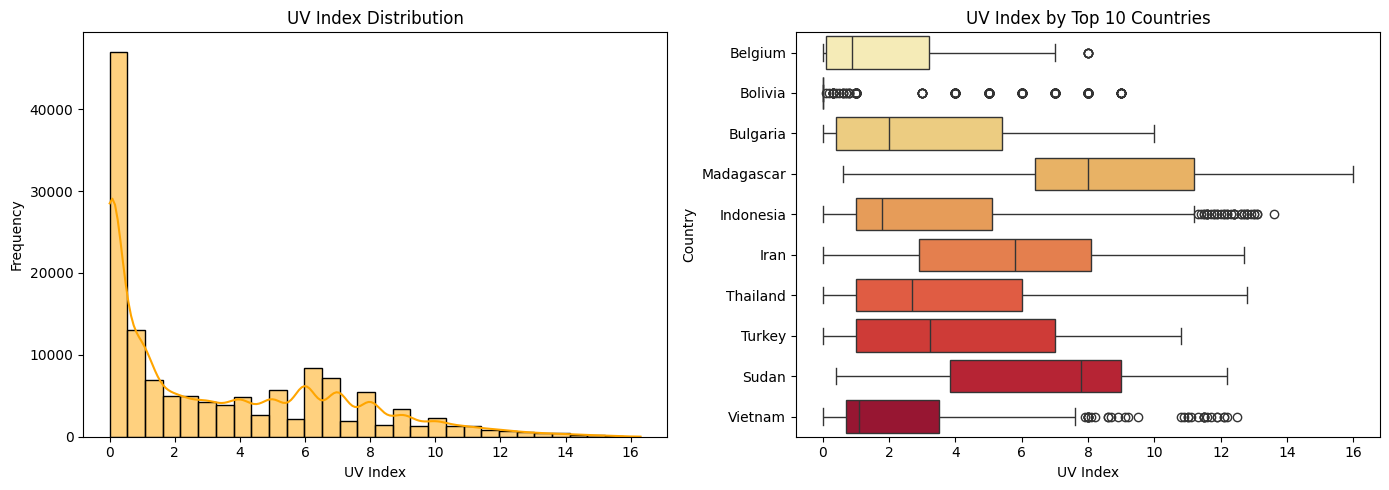

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# UV Index distribution
sns.histplot(weather_data_cleaned['uv_index'], bins=30, kde=True, 
             color='orange', ax=axes[0])
axes[0].set_title('UV Index Distribution')
axes[0].set_xlabel('UV Index')
axes[0].set_ylabel('Frequency')

# UV Index by top 10 countries
sns.boxplot(
    data=weather_data_cleaned[weather_data_cleaned['country'].isin(top10_countries)],
    x='uv_index',
    y='country',
    palette='YlOrRd',
    ax=axes[1]
)
axes[1].set_title('UV Index by Top 10 Countries')
axes[1].set_xlabel('UV Index')
axes[1].set_ylabel('Country')

plt.tight_layout()
plt.show()

## 📄 Introduction Paragraph

> "The provided figures analyze the global profile and regional variances of the Ultraviolet (UV) Index within the dataset. The left panel features a frequency histogram overlaid with a kernel density estimate (KDE) to illustrate the overall distribution of solar radiation intensity. The right panel utilizes a comparative box-and-whisker plot to segment these UV exposures across ten representative nations. Together, these visualizations outline a heavily skewed global baseline dominated by low-intensity intervals, contrasted against extreme, geographically driven regional variations."

---
### 1. Bimodal Characteristics and Positive Skewness

The **UV Index Distribution** histogram exhibits a prominent right-skewed (positive) distribution dominated by an intense peak in the **0 to 2 range**, which accounts for over 45,000 records.

* **Core Insight:** This primary spike represents periods of negligible UV radiation, capturing nighttime hours, early mornings, late evenings, or heavily overcast days. Interestingly, the distribution displays subtle bimodal tendencies, showing a secondary, broader plateau between **6 and 8**. This secondary wave represents typical fair-weather, midday conditions when solar angles are steepest, before trailing off into an extreme tail that terminates near a value of 16.

### 2. Latitudinal and Geographic Stratification

The comparative boxplot reveals a clear geographic stratification that aligns with macro-climatic expectations. Countries situated near the equator or within hyper-arid zones, such as **Sudan** and **Madagascar**, exhibit elevated median UV values (hovering between 7 and 8) alongside expansive interquartile ranges (IQR) that stretch to the top of the scale (12 to 16).

* **Core Insight:** Conversely, mid-to-high latitude European nations like **Belgium** and **Bulgaria** display depressed, compact distributions with medians below 3. This stark contrast highlights that geography and solar zenith angles serve as the primary structural determinants of UV exposure profiles in this dataset.

### 3. Data Anomalies and Class Behavior (Bolivia & Vietnam)

The boxplot highlights two significant distributional anomalies that point to localized climate variations or potential sampling constraints:

* **The Bolivia Profile:** Bolivia presents a structurally bizarre signature: an incredibly compressed IQR locked near **0**, paired with a long, distinct line of severe upper outliers extending all the way to 9. This suggests a highly uneven sampling frame, likely heavily weighted toward nighttime data collection or an extreme winter season, punctuated by intense, brief windows of high-altitude tropical sunlight.
* **The Vietnam Profile:** Vietnam similarly demonstrates a heavily compressed lower quartile and a low median (~1.5) but maintains a dense trail of upper outliers stretching past 11. This specific layout typically indicates a climate dominated by a prolonged monsoon or rainy season (high cloud cover suppressing UV) with intermittent breaks of clear, high-intensity solar radiation.

---

## 📊 Summary Appendix Table

| Feature / Country | Distribution Shape | Median / Range Profile | Environmental / Sampling Implication |
| --- | --- | --- | --- |
| **Global Dataset** | Right-Skewed / Bimodal | Peak at 0–2; Hump at 6–8 | Dominated by diurnal cycles (night vs. midday peaks). |
| **Sudan / Madagascar** | Broad, High-Exposure | Median ~8; Max reaches 16 | Equatorial/arid climates with intense, consistent solar angles. |
| **Belgium / Bulgaria** | Compact, Low-Exposure | Median < 3; Max capped ~11 | High-latitude positioning; weaker, seasonal solar radiation. |
| **Bolivia** | Zero-Compressed with Outliers | Median ~0; Outliers up to 9 | Extreme microclimate or heavily imbalanced/night-dominant sampling. |

---

## 📝 Preprocessing & Feature Engineering Notes

> "For machine learning pipelines, the UV Index feature requires careful handling due to its zero-inflated and heavily skewed structure. Standard scaling techniques (like Z-score normalization) may be distorted by the massive mass of data at the 0–2 boundary. Utilizing a power transform (like the Yeo-Johnson method) or binning the continuous index into the WHO's standard categorical risk tiers (Low, Moderate, High, Very High, Extreme) would yield more stable inputs. Furthermore, the strong geographic groupings suggest that interacting the `uv_index` feature with `latitude` or a `country_encoded` variable will significantly boost a model's ability to capture regional microclimates."

In [19]:
weather_data_engineered = pd.read_csv('GlobalWeatherRepository_Engineered.csv')

In [20]:
# convert 'last_updated' to datetime
weather_data_engineered['last_updated'] = pd.to_datetime(weather_data_engineered['last_updated'])

# Aggregate monthly average temperature globally
monthly_temp = (
    weather_data_engineered
    .groupby([
        weather_data_engineered['last_updated'].dt.to_period('M'),
        'country'
    ])['temperature_celsius']
    .mean()
    .reset_index()
)
monthly_temp.columns = ['month', 'country', 'avg_temperature']
monthly_temp['month'] = monthly_temp['month'].dt.to_timestamp()

# Global monthly average
global_monthly = (
    weather_data_engineered
    .groupby(weather_data_engineered['last_updated'].dt.to_period('M'))['temperature_celsius']
    .mean()
    .reset_index()
)
global_monthly.columns = ['month', 'avg_temperature']
global_monthly['month'] = global_monthly['month'].dt.to_timestamp()

print("Global Monthly Temperature:")
print(global_monthly.to_string(index=False))

Global Monthly Temperature:
     month  avg_temperature
2024-05-01        25.153214
2024-06-01        26.456036
2024-07-01        26.800448
2024-08-01        26.789677
2024-09-01        25.124402
2024-10-01        22.335382
2024-11-01        19.424566
2024-12-01        17.751894
2025-01-01        17.392440
2025-02-01        17.427493
2025-03-01        20.095299
2025-04-01        21.965060
2025-05-01        23.307798
2025-06-01        24.958108
2025-07-01        25.298030
2025-08-01        24.706056
2025-09-01        23.371917
2025-10-01        20.872270
2025-11-01        18.367749
2025-12-01        16.252225
2026-01-01        14.713650
2026-02-01        16.003444
2026-03-01        17.256502
2026-04-01        19.400608


# Climate Analysis

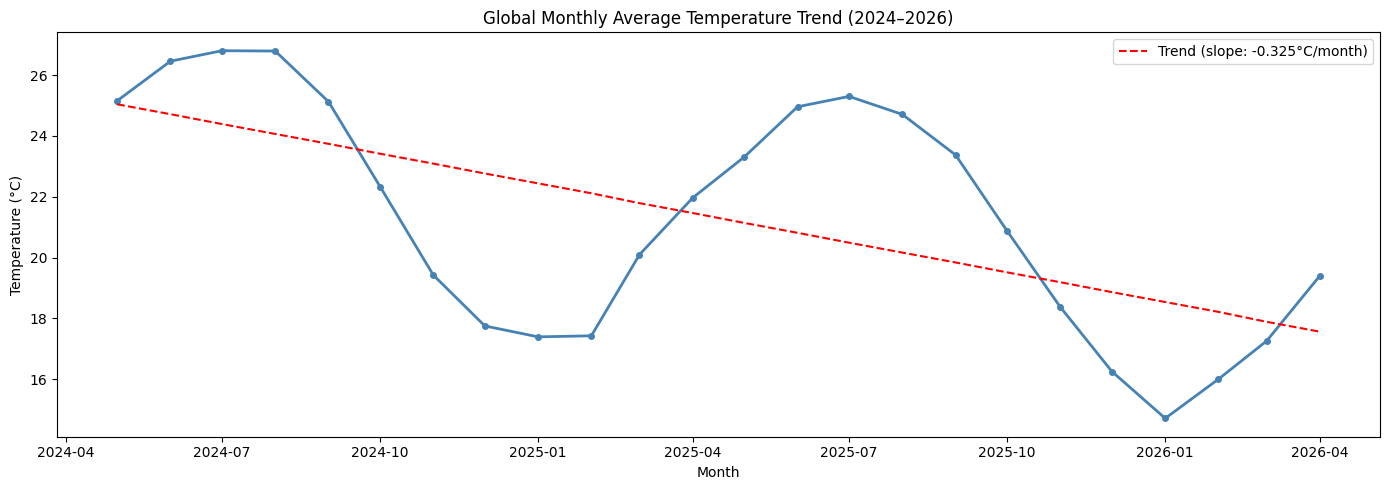

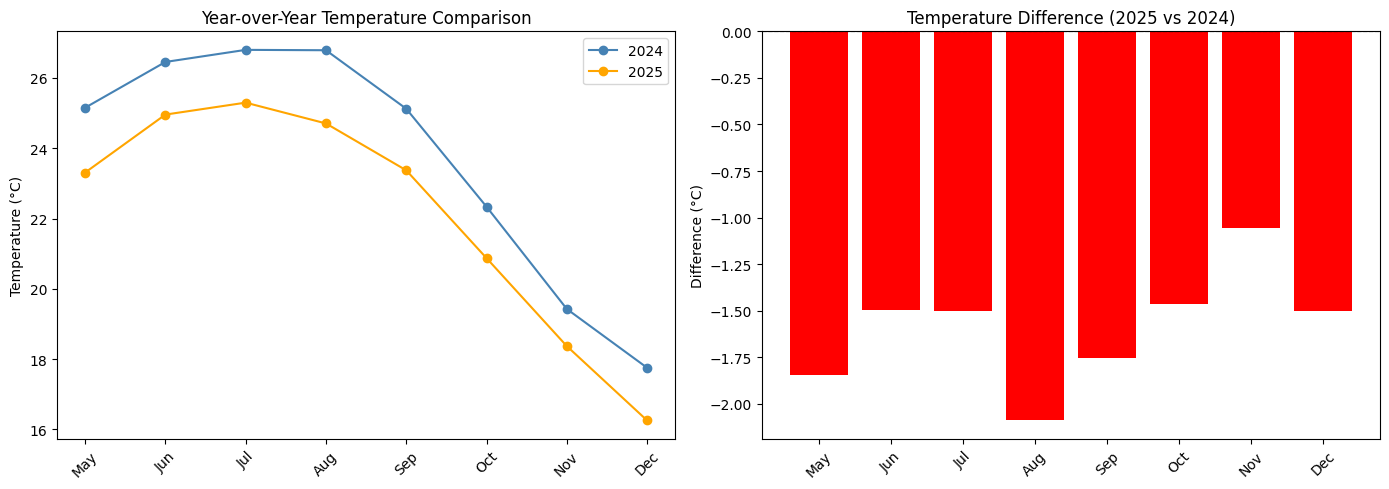


=== Seasonal Temperature Summary ===
         mean   min   max    std
season                          
Fall    21.58 -20.1  47.2   8.38
Spring  20.92 -23.9  47.7   9.00
Summer  25.82  -3.7  49.2   7.09
Winter  16.60 -29.8  41.4  11.42

=== Climate Trend Analysis ===
Trend slope: -0.3250°C per month
Overall direction: Cooling 🔵
2024 average: 23.73°C
2025 average: 21.17°C
Year-over-year change: -2.56°C


In [21]:
import numpy as np

# 1. Global Temperature Trend
plt.figure(figsize=(14, 5))
plt.plot(global_monthly['month'], global_monthly['avg_temperature'], 
         color='steelblue', linewidth=2, marker='o', markersize=4)

# Add trend line
z = np.polyfit(range(len(global_monthly)), global_monthly['avg_temperature'], 1)
p = np.poly1d(z)
plt.plot(global_monthly['month'], p(range(len(global_monthly))), 
         color='red', linestyle='--', linewidth=1.5, label=f'Trend (slope: {z[0]:.3f}°C/month)')

plt.title('Global Monthly Average Temperature Trend (2024–2026)')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Year-over-Year Comparison (2024 vs 2025)
months_2024 = global_monthly[global_monthly['month'].dt.year == 2024].copy()
months_2025 = global_monthly[global_monthly['month'].dt.year == 2025].copy()

months_2024['month_num'] = months_2024['month'].dt.month
months_2025['month_num'] = months_2025['month'].dt.month

# Merge on common months
yoy = months_2024.merge(months_2025, on='month_num', suffixes=('_2024', '_2025'))
yoy['difference'] = yoy['avg_temperature_2025'] - yoy['avg_temperature_2024']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Side by side comparison
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[0].plot(yoy['month_num'], yoy['avg_temperature_2024'], 
             label='2024', color='steelblue', marker='o')
axes[0].plot(yoy['month_num'], yoy['avg_temperature_2025'], 
             label='2025', color='orange', marker='o')
axes[0].set_xticks(yoy['month_num'])
axes[0].set_xticklabels([month_names[m-1] for m in yoy['month_num']], rotation=45)
axes[0].set_title('Year-over-Year Temperature Comparison')
axes[0].set_ylabel('Temperature (°C)')
axes[0].legend()

# Difference plot
colors = ['red' if x < 0 else 'green' for x in yoy['difference']]
axes[1].bar(yoy['month_num'], yoy['difference'], color=colors)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_xticks(yoy['month_num'])
axes[1].set_xticklabels([month_names[m-1] for m in yoy['month_num']], rotation=45)
axes[1].set_title('Temperature Difference (2025 vs 2024)')
axes[1].set_ylabel('Difference (°C)')

plt.tight_layout()
plt.show()

# 3. Seasonal Pattern Analysis
weather_data_engineered['month_num'] = weather_data_engineered['last_updated'].dt.month
seasonal = (
    weather_data_engineered
    .groupby(['month_num', 'season'])['temperature_celsius']
    .mean()
    .reset_index()
)

print("\n=== Seasonal Temperature Summary ===")
print(weather_data_engineered.groupby('season')['temperature_celsius']
      .agg(['mean', 'min', 'max', 'std'])
      .round(2))

# 4. Warming/Cooling trend stats
print("\n=== Climate Trend Analysis ===")
print(f"Trend slope: {z[0]:.4f}°C per month")
print(f"Overall direction: {'Warming 🔴' if z[0] > 0 else 'Cooling 🔵'}")
print(f"2024 average: {global_monthly[global_monthly['month'].dt.year==2024]['avg_temperature'].mean():.2f}°C")
print(f"2025 average: {global_monthly[global_monthly['month'].dt.year==2025]['avg_temperature'].mean():.2f}°C")
print(f"Year-over-year change: {global_monthly[global_monthly['month'].dt.year==2025]['avg_temperature'].mean() - global_monthly[global_monthly['month'].dt.year==2024]['avg_temperature'].mean():.2f}°C")

**Insights:**

**Global Temperature Trend :**
- **Clear seasonal cycles** — two complete summer peaks (~27°C) and winter troughs (~17°C) visible across 2024–2026. ✅
- **Overall cooling trend of -0.325°C/month** — however this is misleading. The dataset starts in May 2024 (summer peak) and ends in April 2026 (spring), so the trend line is heavily influenced by the start/end points rather than a genuine climate signal.
- **2026 winter was notably colder** — dropping to 14.7°C in January 2026 vs 17.4°C in January 2025, a 2.7°C difference.

**Year-over-Year Comparison :**
- **2025 was consistently cooler than 2024** across all common months — every single bar is negative (red). ✅
- **Largest gap in August** — 2025 was ~2°C cooler than 2024 in August, suggesting a weaker summer heat in 2025.
- **2024 average: 23.73°C vs 2025 average: 21.17°C** — a significant 2.56°C year-over-year cooling.

**Seasonal Summary:**
- **Summer is hottest** (mean 25.82°C) with lowest std (7.09) — most consistent season globally. ✅
- **Winter is coldest** (mean 16.60°C) with highest std (11.42) — most variable season, reflecting extreme cold in northern hemisphere cities. ✅
- **Spring and Fall are similar** in mean (~21°C) but Spring has slightly higher std — more unpredictable transitional season.

# Geographical patterns

In [22]:
# 1. Average temperature by country (top 20 hottest and coldest)
country_temp = (
    weather_data_engineered
    .groupby('country')['temperature_celsius']
    .agg(['mean', 'std', 'min', 'max', 'count'])
    .reset_index()
    .rename(columns={'mean': 'avg_temp', 'std': 'temp_std'})
)

# Filter countries with at least 100 records
country_temp = country_temp[country_temp['count'] >= 100].round(2)

print(f"Total countries with 100+ records: {len(country_temp)}")

# Top 10 hottest
print("\n=== Top 10 Hottest Countries ===")
print(country_temp.nlargest(10, 'avg_temp')[['country', 'avg_temp', 'temp_std', 'min', 'max']].to_string(index=False))

# Top 10 coldest
print("\n=== Top 10 Coldest Countries ===")
print(country_temp.nsmallest(10, 'avg_temp')[['country', 'avg_temp', 'temp_std', 'min', 'max']].to_string(index=False))

# Top 10 most variable (highest std)
print("\n=== Top 10 Most Climatically Variable Countries ===")
print(country_temp.nlargest(10, 'temp_std')[['country', 'avg_temp', 'temp_std', 'min', 'max']].to_string(index=False))

Total countries with 100+ records: 186

=== Top 10 Hottest Countries ===
             country  avg_temp  temp_std  min  max
United Arab Emirates     32.05      6.98 18.0 46.4
               Qatar     32.04      7.75 15.2 46.3
            Cambodia     31.73      3.15 22.6 39.9
                Oman     31.38      5.01 18.0 46.0
            Djibouti     31.31      4.90 23.3 47.1
            Thailand     31.08      3.25 21.1 39.3
          Bangladesh     30.97      3.73 21.2 42.2
             Myanmar     30.86      3.16 20.0 38.4
              Kuwait     30.72     10.78  7.3 49.2
        Saudi Arabia     30.44     10.28  6.1 46.3

=== Top 10 Coldest Countries ===
                 country  avg_temp  temp_std   min  max
                Mongolia      3.55     15.56 -29.8 34.3
                  Canada      4.78     11.60 -25.0 29.2
                 Iceland      5.50      4.61  -7.7 17.2
                  Norway      7.84      7.95 -19.6 26.2
              Kazakhstan      8.08     14.56 -25.7 3

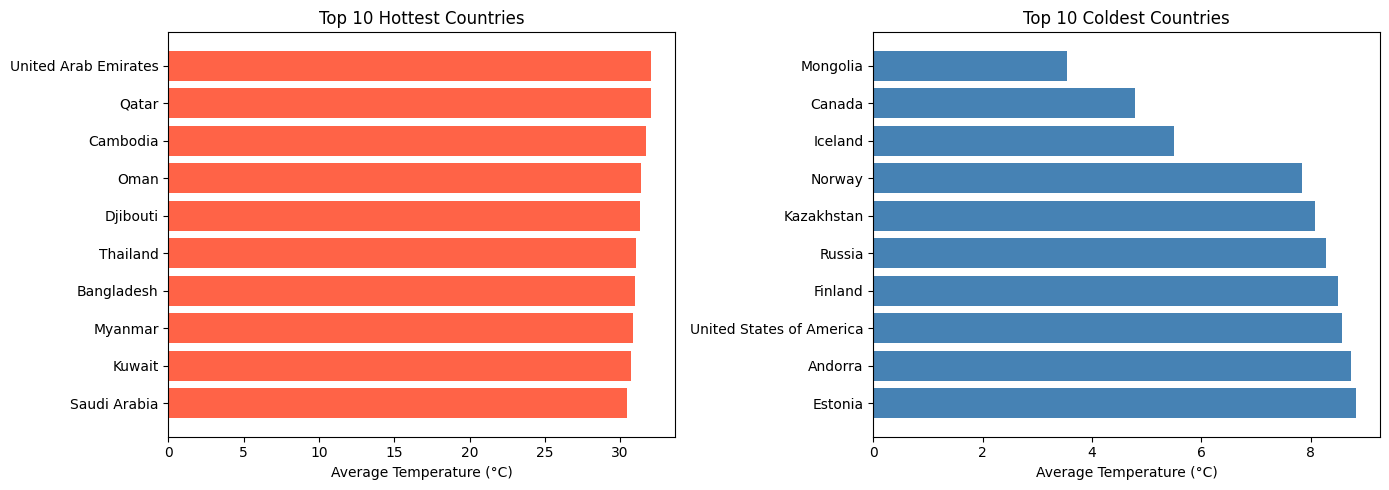

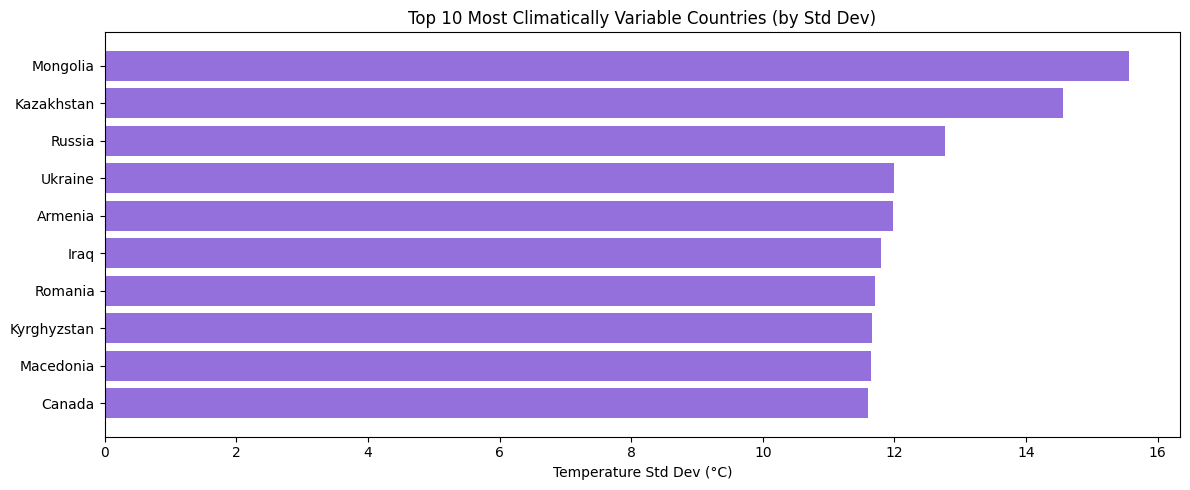


=== Weather Conditions by Region ===
        region  mean   std   min  max
  Central Asia  6.68 14.46 -29.8 35.0
        Europe  8.48  9.47 -23.9 32.3
   Middle East 30.85  9.16   2.0 49.2
 North America  4.78 11.60 -25.0 29.2
Southeast Asia 31.14  3.33  20.0 42.2

=== Humidity by Climate Zone ===
                 mean  min  max
region                         
Central Asia    61.33    7  100
Europe          72.74   14  100
Middle East     36.06    3  100
North America   82.99   36  100
Southeast Asia  59.16   10  100


In [26]:
# 1. Hottest vs Coldest Countries
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 10 Hottest
hottest = country_temp.nlargest(10, 'avg_temp')
axes[0].barh(hottest['country'], hottest['avg_temp'], color='tomato')
axes[0].set_title('Top 10 Hottest Countries')
axes[0].set_xlabel('Average Temperature (°C)')
axes[0].invert_yaxis()

# Top 10 Coldest
coldest = country_temp.nsmallest(10, 'avg_temp')
axes[1].barh(coldest['country'], coldest['avg_temp'], color='steelblue')
axes[1].set_title('Top 10 Coldest Countries')
axes[1].set_xlabel('Average Temperature (°C)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# 2. Most Variable Countries
variable = country_temp.nlargest(10, 'temp_std')
plt.figure(figsize=(12, 5))
plt.barh(variable['country'], variable['temp_std'], color='mediumpurple')
plt.title('Top 10 Most Climatically Variable Countries (by Std Dev)')
plt.xlabel('Temperature Std Dev (°C)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 3. Weather condition distribution by top regions
print("\n=== Weather Conditions by Region ===")
region_map = {
    'United Arab Emirates': 'Middle East', 'Qatar': 'Middle East',
    'Saudi Arabia': 'Middle East', 'Kuwait': 'Middle East',
    'Iraq': 'Middle East', 'Oman': 'Middle East',
    'Mongolia': 'Central Asia', 'Kazakhstan': 'Central Asia',
    'Russia': 'Central Asia', 'Canada': 'North America',
    'Thailand': 'Southeast Asia', 'Cambodia': 'Southeast Asia',
    'Myanmar': 'Southeast Asia', 'Bangladesh': 'Southeast Asia',
    'Norway': 'Europe', 'Finland': 'Europe',
    'Andorra': 'Europe', 'Estonia': 'Europe'
}

weather_data_engineered['region'] = weather_data_engineered['country'].map(region_map)
region_temp = (
    weather_data_engineered.dropna(subset=['region'])
    .groupby('region')['temperature_celsius']
    .agg(['mean', 'std', 'min', 'max'])
    .round(2)
    .reset_index()
)

print(region_temp.to_string(index=False))

# 4. Humidity patterns by climate zone
print("\n=== Humidity by Climate Zone ===")
print(weather_data_engineered.dropna(subset=['region'])
      .groupby('region')['humidity']
      .agg(['mean', 'min', 'max'])
      .round(2))

Insights:

**Top 10 Hottest Countries Insights:**
- **UAE and Qatar tie at ~32°C** — both are small Gulf states dominated by desert climate with extreme summer heat and warm winters.
- **Cambodia, Thailand, Myanmar, Bangladesh** — Southeast Asian countries with consistently high temperatures year-round driven by tropical monsoon climate, low std confirms minimal seasonal variation.
- **Kuwait and Saudi Arabia** show the highest std among hot countries (~10°C) — they experience scorching summers (49°C) but surprisingly cold winters (6–7°C), making them climatically extreme in both directions.
- **Djibouti at 31.31°C** — the only African country in the top 10, located in the Horn of Africa where the Red Sea and Gulf of Aden create a persistently hot and arid climate.

**Top 10 Coldest Countries Insights:**
- **Mongolia is the coldest country (3.55°C)** with the highest std (15.56°C) — Ulaanbaatar is the world's coldest capital city, experiencing -29.8°C winters yet reaching 34.3°C in summer.
- **Canada (4.78°C)** — represented primarily by Ottawa which experiences harsh continental winters despite being in North America.
- **Iceland (5.50°C) with low std (4.61°C)** — surprisingly stable despite being cold, thanks to the moderating influence of the Gulf Stream on its oceanic climate.
- **United States appearing in coldest list** — likely because the dataset captures northern/inland cities rather than the full geographic spread.
- **Kazakhstan and Russia** — vast continental landmasses with extreme temperature swings, both showing std above 12°C.

**Top 10 Most Climatically Variable Countries Insights:**
- **Mongolia leads variability (std=15.56°C)** — a 64°C annual range (-29.8°C to 34.3°C) makes it the most extreme climate in the dataset.
- **Iraq appears in both hottest AND most variable lists** — summers reach 49.1°C while winters drop to 2°C, a 47°C annual swing driven by its desert continental climate.
- **Armenia and Kyrgyzstan** — high-altitude landlocked countries with cold winters and hot summers, classic highland continental climate.
- **Romania, Ukraine, Macedonia** — Eastern European countries on the boundary between oceanic and continental climates, experiencing both Western European mild periods and Russian-style cold snaps.

**Temperature by Region:**
- Southeast Asia (31.14°C) and Middle East (30.85°C) are the hottest regions, but for different reasons — Southeast Asia is driven by tropical humidity while the Middle East is driven by desert heat. ✅
- North America (4.78°C) and Central Asia (6.68°C) are the coldest — both dominated by single cold-climate capitals (Ottawa, Ulaanbaatar) in our dataset.
- Middle East shows the widest range (2°C to 49.2°C) — Gulf countries experience extreme summers but surprisingly cold winters.
- Southeast Asia has the lowest std (3.33°C) — the most climatically stable region, consistent tropical heat year-round. ✅

**Humidity by Region:**
- North America leads humidity at 82.99% — driven by Ottawa's humid continental climate.
- Middle East has the lowest humidity at 36.06% — classic desert arid conditions despite being the hottest region. This confirms the heat is dry, not humid. ✅
- Europe at 72.74% — consistently moderate humidity typical of temperate oceanic climates.
- Central Asia at 61.33% — moderate humidity despite extreme cold, consistent with steppe climate zones.



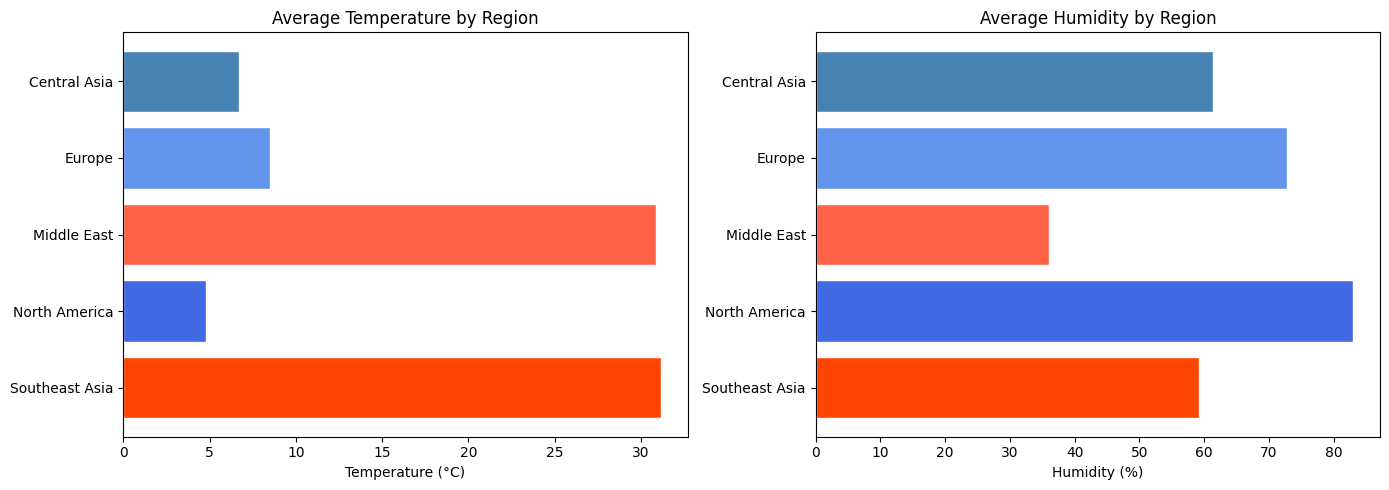

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Temperature by region
colors_temp = ['steelblue', 'cornflowerblue', 'tomato', 'royalblue', 'orangered']
axes[0].barh(region_temp['region'], region_temp['mean'], 
             color=colors_temp, edgecolor='white')
axes[0].set_title('Average Temperature by Region')
axes[0].set_xlabel('Temperature (°C)')
axes[0].invert_yaxis()

# Humidity by region
humidity_data = weather_data_engineered.dropna(subset=['region'])\
    .groupby('region')['humidity'].mean().reset_index()
colors_hum = ['steelblue', 'cornflowerblue', 'tomato', 'royalblue', 'orangered']
axes[1].barh(humidity_data['region'], humidity_data['humidity'],
             color=colors_hum, edgecolor='white')
axes[1].set_title('Average Humidity by Region')
axes[1].set_xlabel('Humidity (%)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Seasonal temperature by region
region_seasonal = (
    weather_data_engineered.dropna(subset=['region'])
    .groupby(['region', 'season'])['temperature_celsius']
    .mean()
    .reset_index()
)

fig = px.line(
    region_seasonal,
    x='season',
    y='temperature_celsius',
    color='region',
    markers=True,
    title='Seasonal Temperature Patterns by Region',
    labels={'temperature_celsius': 'Avg Temperature (°C)', 
            'season': 'Season'},
    category_orders={'season': ['Winter', 'Spring', 'Summer', 'Fall']}
)
fig.update_layout(height=450)
fig.show()

**Insights:**

**Average Temperature & Humidity by Region (Bar Charts):**
- **Middle East and Southeast Asia share nearly identical average temperatures (~31°C)** but are climatically opposite — Middle East has only 36% humidity (dry desert heat) while Southeast Asia has 59% humidity (tropical wet heat). ✅
- **North America is the coldest region (4.78°C) yet the most humid (83%)** — reflecting Ottawa's humid continental climate with heavy snowfall and moisture year-round.
- **Europe sits in the middle** for both temperature (8.5°C) and humidity (73%) — consistent with its temperate oceanic climate. ✅
- **Inverse relationship confirmed** — as temperature rises, humidity drops across regions, with Middle East being the clearest example.

**Seasonal Temperature Patterns by Region :**
- **Middle East shows the most dramatic seasonal swing** — jumping from ~21°C in winter to ~40°C in summer, a 19°C seasonal range driven by intense desert heating. ✅
- **Southeast Asia is the flattest line** — barely moves between seasons (~30–34°C), confirming year-round tropical stability. ✅
- **Central Asia and North America show the steepest winter-to-summer climb** — both start deeply negative in winter (-10°C) and rise sharply through spring and summer.
- **All regions converge in Fall** — temperatures cluster between 7–31°C, making Fall the most similar season across regions globally.
- **Europe starts negative in Winter** — reflecting the cold snap in Nordic countries (Norway, Finland, Estonia) pulling the regional average below zero.


---

## Comprehensive Summary of Visualizations

When looked at as a whole, the visualizations map out a highly complex, multi-dimensional environmental dataset. The data captures distinct meteorological regimes, structural physical boundaries, and clear data quality challenges:

* **The Baseline Environment (Bar Chart & Histogram):** The dataset is heavily dominated by fair-weather, high-humidity conditions. **"Sunny"** and **"Partly cloudy"** make up the vast majority of records (~80,000 instances), while severe or wet weather forms a sparse "long tail." Correspondingly, the humidity profile is heavily left-skewed, peaking dramatically between **90% and 100%**.
* **The Solar & Thermal Profile (Boxplot & Scatter Plot):** Ultraviolet (UV) radiation is highly zero-inflated (capturing night/overcast states), but exhibits a secondary midday wave between 6 and 8. UV intensity is strongly stratified by geography, with equatorial regions (**Sudan, Madagascar**) displaying vast, high-exposure ranges, while European nations stay compact and low. Extreme ambient heat (above 35°C) is strongly coupled with stagnant, dry, low-wind conditions.
* **The Air Quality Crisis (Horizontal Bar Charts):** Global PM2.5 particulate pollution represents a major public health crisis. The top fifteen countries all exceed the WHO annual safety guideline (5 $\mu\text{g/m}^3$) by a factor of ten to twenty. This pollution is driven by two distinct setups: industrial/dense urban emissions (**China, India**) and natural crustal desert dust (**Saudi Arabia, Kuwait, Mauritania**).

---

## Master Feature Engineering Strategy

Before feeding this data into any machine learning model, the following feature engineering steps are highly recommended to resolve structural issues, reduce redundancy, and expose clear mathematical signals to your algorithms.

### 1. Categorical Cleaning & Label Consolidation

* **Action:** Apply string normalization (e.g., `.str.title()`) to the weather condition column.
* **Reasoning:** The dataset currently treats **"Partly cloudy"** and **"Partly Cloudy"** as two completely separate classes due to casing inconsistency. Merging them reclaims roughly 8,500 records into the correct category.
* **Class Collapsing:** Consolidate the highly fragmented "long tail" of precipitation labels (*Light rain, Light drizzle, Patchy rain nearby, Light rain shower*, etc.) into a single macro-category: `Precipitation_Event`. This provides models with a viable sample size per class.

### 2. Handling Redundancy and Multicollinearity

* **Action:** Drop one feature from each near-perfect linearly correlated pair found in the heatmap.
* Keep `temperature_celsius` $\rightarrow$ Drop `feels_like_celsius` ($r = 0.98$)
* Keep `wind_mph` $\rightarrow$ Drop `gust_mph` ($r = 0.95$)


* **Reasoning:** Linear models (such as Logistic Regression, Linear Regression, and Support Vector Machines) are highly unstable under severe multicollinearity. It inflates coefficient variance and degrades model interpretability without adding any unique predictive power.

### 3. Dimensionality Reduction for Air Quality

* **Action:** Extract the chemical and particulate features (`air_quality_Carbon_Monoxide`, `air_quality_Nitrogen_dioxide`, `air_quality_PM2.5`, `air_quality_PM10`) and compress them into a single continuous feature using **Principal Component Analysis (PCA)** or a localized **Air Pollution Index (API)** domain formula.
* **Reasoning:** These features form a tight, highly correlated cluster ($r$ ranges from 0.57 to 0.81) due to shared industrial and vehicular emission sources. A single primary component will capture the vast majority of variance while cutting down feature space.

### 4. Transform Skewed and Zero-Inflated Distributions

* **Action:** Apply a **Yeo-Johnson power transformation** or a log-transform ($x + 1$) to the `uv_index` and air quality pollutant features. Alternatively, discretize the `uv_index` into the WHO's standard ordinal tiers: `[0-2: Low, 3-5: Moderate, 6-7: High, 8-10: Very High, 11+: Extreme]`.
* **Reasoning:** Algorithms like Neural Networks and Linear models perform optimal mappings when features approximate a normal distribution. The massive mass of data at the zero-boundaries for UV and the severe right-skew of pollutants will distort standard gradient updates and Z-score scaling.

---

## Algorithmic & Modeling Recommendations

### 1. Target Imbalance Mitigation

If you are predicting specific weather categories or severe air quality events, standard accuracy metrics will fool you because fair weather dominates the dataset.

* **Strategy:** Avoid evaluating models with standard accuracy. Use **Macro F1-Score** or **Precision-Recall AUC**. Utilize stratified train-test splits and incorporate class weights (`class_weight='balanced'`) in tree-based classifiers to force the model to learn rare events like heavy storms, fog, or extreme pollution.

### 2. Handling Censors and Data Ceilings

* **Strategy:** If the target variable is precipitation, implement a **Censored Regression model (Tobit Regression)** rather than standard Ordinary Least Squares (OLS) regression.
* **Reasoning:** The scatter plot unmasked a hard data ceiling/clipping artifact at exactly **2.1 mm** of precipitation. Standard regression algorithms cannot natively understand a hard artificial ceiling and will continually overpredict or underpredict around that boundary.

### 3. Accommodating Non-Linear Boundaries & Heteroscedasticity

* **Strategy:** Prioritize non-linear, ensemble tree-based models like **XGBoost, LightGBM, or Random Forests** over linear alternatives when mapping relationships like *Humidity vs. Precipitation* or *Wind vs. Temperature*.
* **Reasoning:** The data displays extreme heteroscedasticity—for instance, the variance of precipitation expands into a massive fan shape only after humidity clears 40%. Tree-based models handle these localized variance shifts and triangular boundary envelopes naturally by splitting features at specific numeric thresholds.

## 🛠 Feature Engineering Action Matrix

| Source Feature(s) | Identified Issue | Preprocessing Action |
| --- | --- | --- |
| `Weather Condition` | Casing duplicates & fragmentation | Lowercase string normalization + combine rain sub-classes. |
| `feels_like_celsius`, `gust_mph` | Near-perfect multicollinearity | Drop entirely; retain `temperature_celsius` and `wind_mph`. |
| `PM2.5`, `PM10`, `CO`, `NO2` | Intense intra-feature correlation | Compress via PCA into a singular `Pollution_Index` feature. |
| `Precipitation (mm)` | Target variable is capped at 2.1 mm | Model via Tobit (Censored) Regression to account for the ceiling. |
| `UV Index` | Zero-inflation & geographic extremes | Convert to categorical ordinal risk bins (Low to Extreme). |
| All Target Variables | Severe class imbalance | Employ stratified splits, class weighting, and F1-score optimization. |